<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/feature_scaling/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


# Our small dataset for demonstration
months = np.array([1, 2, 3, 4,5,6,7,8,9])  # Independent variable
sales = np.array([100, 120, 130, 125, 135, 130, 140, 135, 145])  # Dependent variable

df = pd.DataFrame({
    "Month": months,
    "Sales": sales
})

df.to_excel("Monthly_sales.xlsx", index=False)

Our small dataset:
X: [1 2 3 4 5 6 7 8 9]
Y: [100 120 130 125 135 130 140 135 145]


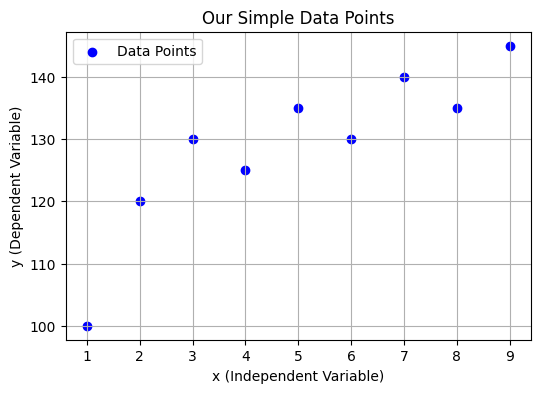

In [15]:
df = pd.read_excel("/content/Monthly_sales.xlsx")
X = np.array(df["Month"])
Y = np.array(df["Sales"])

print("Our small dataset:")
print(f"X: {X}")
print(f"Y: {Y}")

# Let's visualize our data points
plt.figure(figsize=(6, 4))
plt.scatter(X, Y, color='blue', label='Data Points')
plt.title('Our Simple Data Points')
plt.xlabel('x (Independent Variable)')
plt.ylabel('y (Dependent Variable)')
plt.grid(True)
plt.legend()
plt.show()

In [16]:
# Calculate the means of X and Y
mean_x = np.mean(X)
mean_y = np.mean(Y)

print(f"Mean of x (\u00afx): {mean_x}")
print(f"Mean of y (\u00afy): {mean_y}\n")

# Calculate the numerator and denominator for the slope formula
numerator = np.sum((X - mean_x) * (Y - mean_y))
denominator = np.sum((X - mean_x)**2)

# Calculate the slope (m)
m = numerator / denominator

# Calculate the intercept (b)
b = mean_y - m * mean_x

print(f"Calculated Slope (m): {m:.2f}")
print(f"Calculated Intercept (b): {b:.2f}")

# Now, let's make predictions using our calculated line
y_pred_math = b + m * X
print(f"\nPredicted y values (Mathematical Approach): {y_pred_math}")

Mean of x (¯x): 5.0
Mean of y (¯y): 128.88888888888889

Calculated Slope (m): 4.17
Calculated Intercept (b): 108.06

Predicted y values (Mathematical Approach): [112.22222222 116.38888889 120.55555556 124.72222222 128.88888889
 133.05555556 137.22222222 141.38888889 145.55555556]


In [17]:
from sklearn.linear_model import LinearRegression

# Scikit-learn expects the input X to be a 2D array (even for a single feature)
# So, we need to reshape our X array.
x_reshaped = X.reshape(-1, 1)

# Create a Linear Regression model object
model = LinearRegression()

# Train the model using our data
model.fit(x_reshaped, Y)

# Get the learned coefficients (slope and intercept)
m_sklearn = model.coef_[0]
b_sklearn = model.intercept_

print(f"Slope (m) from Scikit-learn: {m_sklearn:.2f}")
print(f"Intercept (b) from Scikit-learn: {b_sklearn:.2f}")

# Make predictions using the trained model
y_pred_sklearn = model.predict(x_reshaped)
print(f"\nPredicted y values (Scikit-learn): {y_pred_sklearn}")

Slope (m) from Scikit-learn: 4.17
Intercept (b) from Scikit-learn: 108.06

Predicted y values (Scikit-learn): [112.22222222 116.38888889 120.55555556 124.72222222 128.88888889
 133.05555556 137.22222222 141.38888889 145.55555556]


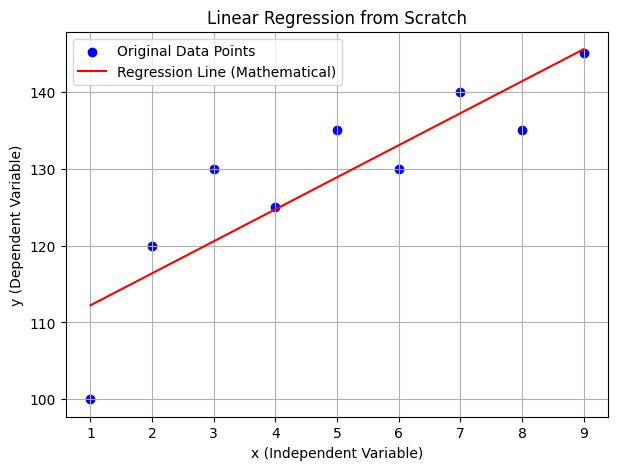

In [18]:
# Plot the original data points and the regression line
plt.figure(figsize=(7, 5))
plt.scatter(X, Y, color='blue', label='Original Data Points')
plt.plot(X, y_pred_math, color='red', label='Regression Line (Mathematical)')
plt.title('Linear Regression from Scratch')
plt.xlabel('x (Independent Variable)')
plt.ylabel('y (Dependent Variable)')
plt.grid(True)
plt.legend()
plt.show()

New x value for prediction: 10
Predicted y (Mathematical Approach): 149.72
Predicted y (Scikit-learn Approach): 149.72


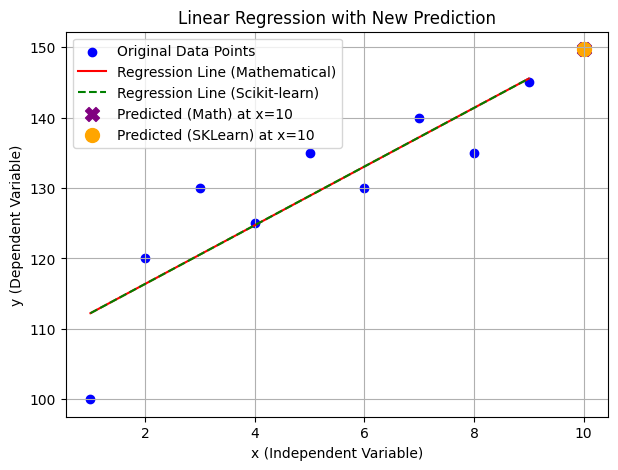

New x value for prediction: 11
Predicted y (Mathematical Approach): 153.89
Predicted y (Scikit-learn Approach): 153.89


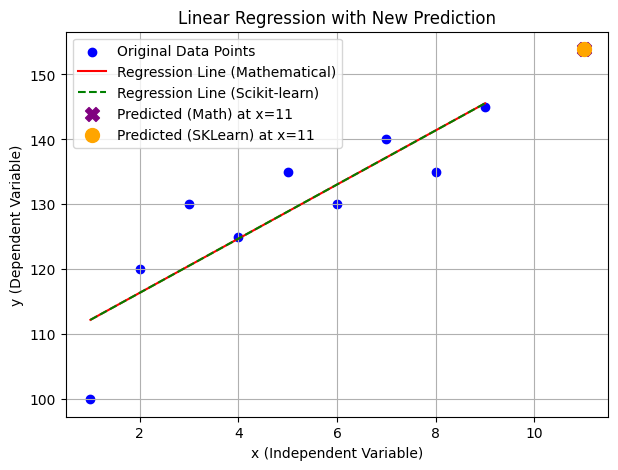

New x value for prediction: 12
Predicted y (Mathematical Approach): 158.06
Predicted y (Scikit-learn Approach): 158.06


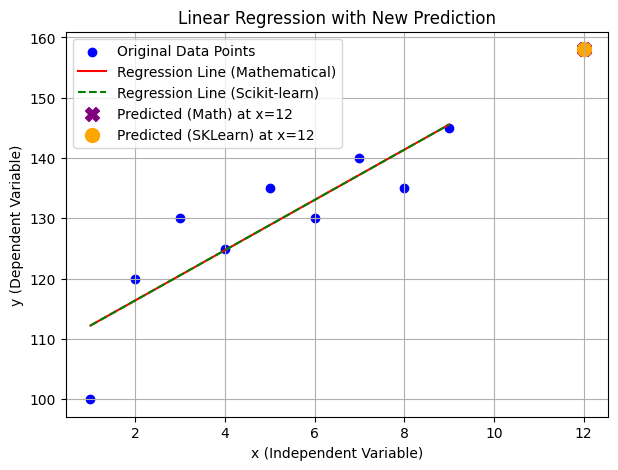

In [19]:
# Let's try to predict for a new x value
# You can change this value to experiment!
for i in range(10,13):
  new_xs = i

  print(f"New x value for prediction: {new_xs}")

  # --- Prediction using the Mathematical Model ---
  predicted_y_math = m * new_xs + b
  print(f"Predicted y (Mathematical Approach): {predicted_y_math:.2f}")

  # --- Prediction using the Scikit-learn Model ---
  # Scikit-learn's predict method also expects a 2D array, even for a single input
  predicted_y_sklearn = model.predict(np.array([[new_xs]]))[0]
  print(f"Predicted y (Scikit-learn Approach): {predicted_y_sklearn:.2f}")

  # Let's visualize this prediction as well
  plt.figure(figsize=(7, 5))
  plt.scatter(X, Y, color='blue', label='Original Data Points')
  plt.plot(X, y_pred_math, color='red', label='Regression Line (Mathematical)')
  plt.plot(X, y_pred_sklearn, color='green', linestyle='--', label='Regression Line (Scikit-learn)') # Optional: plot both lines for comparison
  plt.scatter(new_xs, predicted_y_math, color='purple', marker='X', s=100, label=f'Predicted (Math) at x={new_xs:.0f}')
  plt.scatter(new_xs, predicted_y_sklearn, color='orange', marker='o', s=100, label=f'Predicted (SKLearn) at x={new_xs:.0f}')
  plt.title('Linear Regression with New Prediction')
  plt.xlabel('x (Independent Variable)')
  plt.ylabel('y (Dependent Variable)')
  plt.grid(True)
  plt.legend()
  plt.show()